<a href="https://colab.research.google.com/github/aitoufkir-khadija2004/Transfer-Learning---tf_flowers/blob/main/Transfer_Learning_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Transfer Learning — TP Deep Learning
**Dataset :** TF Flowers (5 classes, 3 670 images)  
**Modèles :** CNN From Scratch · VGG16 · ResNet50 · MobileNetV2  


<div style="border-left:8px solid #0B5394;background:#EAF2FF;padding:14px 16px;border-radius:10px;margin:12px 0;">
<h2 style="margin:0 0 6px 0;color:#0B5394;">Objectifs de l'évaluation</h2>
<ol style="color:#1f1f1f;line-height:1.6;">
  <li>Choisir un dataset de classification d'images</li>
  <li>Entraîner un CNN from scratch original et justifié</li>
  <li>Appliquer le Transfer Learning avec <b>3 modèles pré-entraînés</b> (VGG16, ResNet50, MobileNetV2)</li>
  <li>Comparer les performances </li>
</ol>
</div>


##  1. Dataset — TF Flowers


**Source** : [tf_flowers](https://www.tensorflow.org/datasets/catalog/tf_flowers)

 **Nombre d'images**:  3 670

 **Nombre de classes** : 5 (daisy, dandelion, roses, sunflowers, tulips)






## ⚙️ 2. Imports & Configuration

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score)

print(f" TensorFlow {tf.__version__}")
print(f"GPU disponible : {len(tf.config.list_physical_devices('GPU')) > 0}")

# Hyperparamètres globaux
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE


 TensorFlow 2.19.0
GPU disponible : False


## 📥 3. Chargement et visualisation du dataset

In [2]:
# Chargement depuis tensorflow_datasets (aucun téléchargement manuel requis)
(train_raw, val_raw, test_raw), info = tfds.load(
    'tf_flowers',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    with_info=True,
    as_supervised=True,
    shuffle_files=True
)

CLASS_NAMES  = info.features['label'].names
NUM_CLASSES  = info.features['label'].num_classes
TOTAL_IMAGES = info.splits['train'].num_examples

print(f"Classes ({NUM_CLASSES}) : {CLASS_NAMES}")
print(f"Total images  : {TOTAL_IMAGES}")
print(f"Train / Val / Test : {int(TOTAL_IMAGES*0.70)} / {int(TOTAL_IMAGES*0.15)} / {int(TOTAL_IMAGES*0.15)}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.E7I80V_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Classes (5) : ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Total images  : 3670
Train / Val / Test : 2569 / 550 / 550


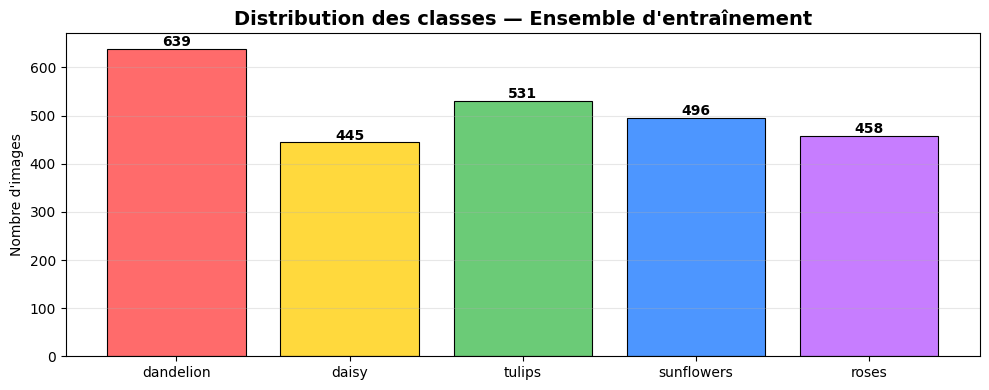

→ Dataset légèrement déséquilibré — nous utiliserons des métriques pondérées (weighted F1)


In [3]:
# ── Distribution des classes ────────────────────────────────────────────────
labels_list = [label.numpy() for _, label in train_raw]
unique, counts = np.unique(labels_list, return_counts=True)

plt.figure(figsize=(10, 4))
bars = plt.bar(CLASS_NAMES, counts, color=['#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF'],
               edgecolor='black', linewidth=0.8)
plt.title('Distribution des classes — Ensemble d\'entraînement', fontsize=14, fontweight='bold')
plt.ylabel('Nombre d\'images')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             str(count), ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Dataset légèrement déséquilibré — nous utiliserons des métriques pondérées (weighted F1)")


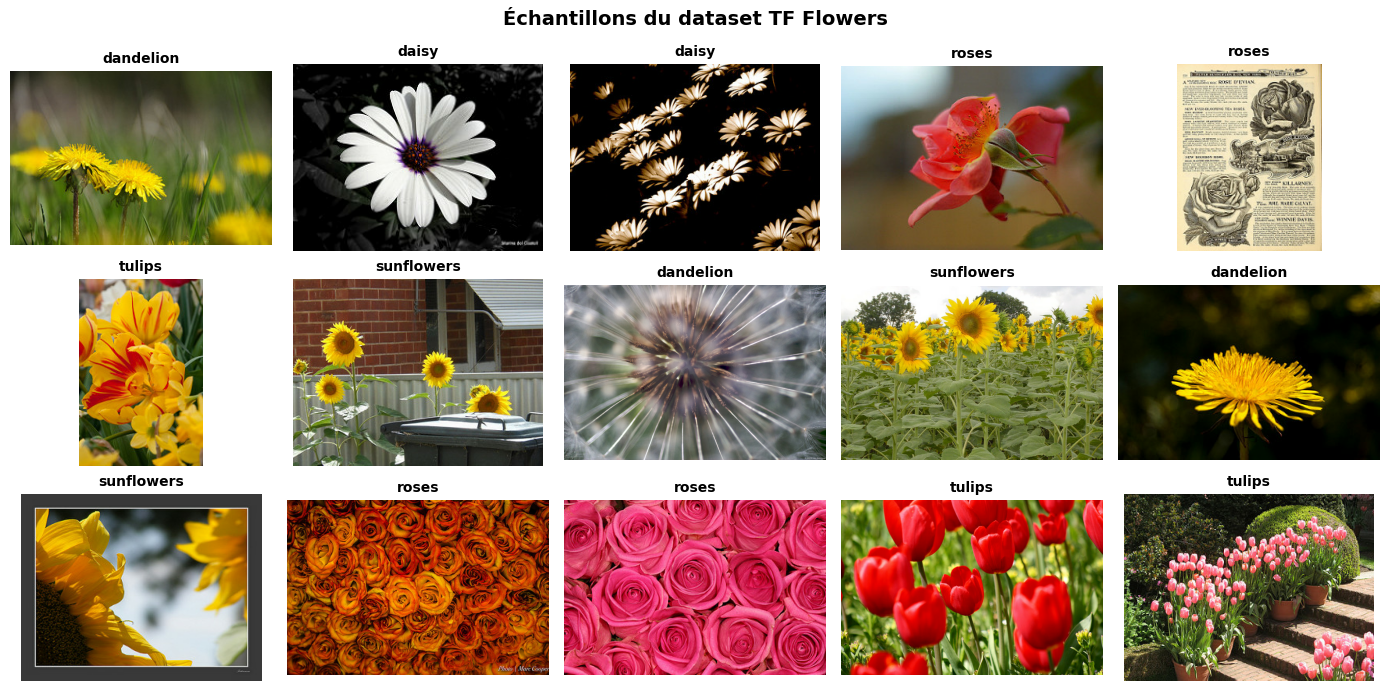

In [4]:
# ── Visualisation d'échantillons ────────────────────────────────────────────
plt.figure(figsize=(14, 7))
sample_batch = list(train_raw.shuffle(200).take(15))
for i, (img, lbl) in enumerate(sample_batch):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.numpy().astype("uint8"))
    plt.title(CLASS_NAMES[lbl.numpy()], fontsize=10, fontweight='bold')
    plt.axis("off")
plt.suptitle('Échantillons du dataset TF Flowers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 🔧 4. Pipeline de données & Augmentation

In [5]:
# ── Redimensionnement (sans normalisation — gérée par chaque backbone) ──────
def resize_img(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

# ── Augmentation (uniquement sur le train) ───────────────────────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.10),
], name="data_augmentation")

def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label

# ── Construction des datasets finaux ─────────────────────────────────────────
train_ds = (train_raw
            .map(resize_img, num_parallel_calls=AUTOTUNE)
            .map(augment,    num_parallel_calls=AUTOTUNE)
            .cache()
            .shuffle(1000, seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds   = (val_raw
            .map(resize_img, num_parallel_calls=AUTOTUNE)
            .cache()
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds  = (test_raw
            .map(resize_img, num_parallel_calls=AUTOTUNE)
            .cache()
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

print("✅ Pipelines prêts :")
print(f"   Train  → {train_ds}")
print(f"   Val    → {val_ds}")
print(f"   Test   → {test_ds}")


✅ Pipelines prêts :
   Train  → <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
   Val    → <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
   Test   → <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


## 🛠️ 5. Fonctions utilitaires

In [6]:
def plot_history(history, title, color_acc='#4ECDC4', color_loss='#FF6B6B'):
    """Trace les courbes accuracy et loss train/validation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train',      color=color_acc, linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', color=color_acc, linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Époques'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train',      color=color_loss, linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', color=color_loss, linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} — Loss', fontweight='bold')
    axes[1].set_xlabel('Époques'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def build_transfer_model(base_model, preprocess_fn, num_classes, name):
    """Construit un modèle Transfer Learning avec backbone gelé."""
    inputs = layers.Input(shape=(224, 224, 3))
    x = preprocess_fn(inputs)                        # normalisation spécifique au backbone
    x = base_model(x, training=False)               # backbone gelé
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name=name)


def get_predictions(model, dataset):
    """Récupère les vraies étiquettes et les prédictions sur un dataset."""
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)


def early_stop_cb(patience=5):
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=patience,
        restore_best_weights=True, verbose=1
    )

print("✅ Fonctions utilitaires définies")


✅ Fonctions utilitaires définies


---
## 🏗️ PARTIE 1 — CNN From Scratch

### Justification de l'architecture
Le CNN est conçu avec **4 blocs Conv + BatchNorm + MaxPooling** pour extraire progressivement des features de bas niveau vers haut niveau.  
- **BatchNormalization** : stabilise l'entraînement, réduit la sensibilité au learning rate  
- **GlobalAveragePooling** : remplace Flatten pour réduire le surapprentissage  
- **Dropout(0.5)** : régularisation face au manque de données  

⚠️ *Avec seulement ~2 570 images en train, ce réseau souffrira d'overfitting — c'est l'effet attendu à démontrer.*


In [7]:
scratch_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),                          # normalisation [0,1]

    # Bloc 1 — features bas niveau (bords, textures)
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Bloc 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Bloc 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Bloc 4 — features haut niveau (formes, structures)
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    # Tête de classification
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="CNN_From_Scratch")

scratch_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

scratch_model.summary()


Model: "CNN_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,413 (1.74 MB)

 Trainable params: 456,453 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
history_scratch = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[early_stop_cb(patience=5)],
    verbose=1
)


Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 536s 6s/step - accuracy: 0.4768 - loss: 1.3261 - val_accuracy: 0.2668 - val_loss: 1.9758
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 531s 6s/step - accuracy: 0.5391 - loss: 1.1579 - val_accuracy: 0.2668 - val_loss: 2.1773
Epoch 3/20
28/81 ━━━━━━━━━━━━━━━━━━━━ 5:16 6s/step - accuracy: 0.5487 - loss: 1.1219

KeyboardInterrupt: 

In [ ]:
plot_history(history_scratch, "CNN From Scratch", color_acc='#FF6B6B', color_loss='#C0392B')

scratch_val_acc = max(history_scratch.history['val_accuracy'])
scratch_train_acc = max(history_scratch.history['accuracy'])
gap = scratch_train_acc - scratch_val_acc
print(f"\n📊 From Scratch — Résultats :")
print(f"   Best Train Accuracy      : {scratch_train_acc*100:.1f}%")
print(f"   Best Validation Accuracy : {scratch_val_acc*100:.1f}%")
print(f"   Gap (overfitting)        : {gap*100:.1f}%")
if gap > 0.15:
    print("   ⚠️  Overfitting significatif détecté — attendu avec peu de données")


---
## 🔁 PARTIE 2 — Transfer Learning (Feature Extraction)

### Principe
Les 3 backbones pré-entraînés sur **ImageNet** (1.2M images, 1000 classes) ont appris des représentations universelles.  
En **gelant** leurs poids (`trainable=False`), on utilise ces features sans les modifier.  
Seule la **tête de classification** est entraînée sur nos 5 classes de fleurs.

| Modèle | Paramètres | Points forts |
|---|---|---|
| **VGG16** | 138M | Architecture simple, features stables |
| **ResNet50** | 25M | Résidus — évite la disparition du gradient |
| **MobileNetV2** | 3.4M | Léger, rapide, efficace |


### 2.1 — VGG16 (Feature Extraction)

In [ ]:
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg_base.trainable = False

vgg_model = build_transfer_model(vgg_base, vgg_preprocess, NUM_CLASSES, "VGG16_FeatureExtraction")
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Paramètres entraînables VGG16 : {vgg_model.trainable_variables.__len__()} tenseurs")
vgg_model.summary()


In [ ]:
history_vgg = vgg_model.fit(
    train_ds, validation_data=val_ds,
    epochs=6, callbacks=[early_stop_cb(patience=4)], verbose=1
)
plot_history(history_vgg, "VGG16 — Feature Extraction", color_acc='#4ECDC4')


### 2.2 — ResNet50 (Feature Extraction)

In [ ]:
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
resnet_base.trainable = False

resnet_model = build_transfer_model(resnet_base, resnet_preprocess, NUM_CLASSES, "ResNet50_FeatureExtraction")
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_resnet = resnet_model.fit(
    train_ds, validation_data=val_ds,
    epochs=6, callbacks=[early_stop_cb(patience=4)], verbose=1
)
plot_history(history_resnet, "ResNet50 — Feature Extraction", color_acc='#45B7D1')


### 2.3 — MobileNetV2 (Feature Extraction)

In [ ]:
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
mobilenet_base.trainable = False

mobilenet_model = build_transfer_model(mobilenet_base, mobilenet_preprocess, NUM_CLASSES, "MobileNetV2_FeatureExtraction")
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_ds, validation_data=val_ds,
    epochs=6, callbacks=[early_stop_cb(patience=4)], verbose=1
)
plot_history(history_mobilenet, "MobileNetV2 — Feature Extraction", color_acc='#96CEB4')


---
## 🎯 PARTIE 3 — Fine-Tuning (Dégel contrôlé)

### Stratégie
Après la convergence en feature extraction, on **dégèle les dernières couches** de ResNet50 (30 dernières sur 175)  
pour adapter les features haut niveau à notre domaine (fleurs ≠ ImageNet générique).

**Précautions :**
- Learning rate très faible (`1e-5`) pour ne pas détruire les features pré-apprises
- On repart des **poids déjà optimisés** par la phase Feature Extraction
- On gèle les premières couches (features bas niveau = universelles)


In [ ]:
# Dégel des 30 dernières couches de ResNet50
resnet_base.trainable = True
UNFREEZE_FROM = len(resnet_base.layers) - 30

for i, layer in enumerate(resnet_base.layers):
    layer.trainable = i >= UNFREEZE_FROM

frozen    = sum(1 for l in resnet_base.layers if not l.trainable)
trainable = sum(1 for l in resnet_base.layers if l.trainable)
print(f"ResNet50 — Couches gelées : {frozen} | Dégelées : {trainable}")

# Recompilation avec LR très faible
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_finetune = resnet_model.fit(
    train_ds, validation_data=val_ds,
    epochs=5, callbacks=[early_stop_cb(patience=4)], verbose=1
)
plot_history(history_finetune, "ResNet50 — Fine-Tuning", color_acc='#F8A5C2')

print(f"\n📈 Amélioration après Fine-Tuning :")
print(f"   Feature Extraction : {max(history_resnet.history['val_accuracy'])*100:.1f}%")
print(f"   Fine-Tuning        : {max(history_finetune.history['val_accuracy'])*100:.1f}%")


---
## 📊 PARTIE 4 — Analyse Comparative Complète


In [ ]:
# ── Évaluation sur le test set ──────────────────────────────────────────────
model_configs = [
    (scratch_model,   "CNN From Scratch"),
    (vgg_model,       "VGG16 (Feature Extraction)"),
    (resnet_model,    "ResNet50 (Fine-Tuned)"),
    (mobilenet_model, "MobileNetV2 (Feature Extraction)")
]

results_list = []
predictions_dict = {}

for model, name in model_configs:
    y_true, y_pred = get_predictions(model, test_ds)
    predictions_dict[name] = (y_true, y_pred)

    acc  = np.mean(y_true == y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')

    results_list.append({'Modèle': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    print(f"✅ {name} évalué")

results_df = pd.DataFrame(results_list).set_index('Modèle')
print("\n" + "="*70)
print("TABLEAU COMPARATIF — Métriques sur le Test Set")
print("="*70)
print(results_df.applymap(lambda x: f"{x*100:.2f}%").to_string())


In [ ]:
# ── Rapport de classification détaillé ──────────────────────────────────────
for name, (y_true, y_pred) in predictions_dict.items():
    print(f"\n{'='*60}")
    print(f"Rapport — {name}")
    print('='*60)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


In [ ]:
# ── Graphique comparatif des métriques ──────────────────────────────────────
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
n_models  = len(results_df)
x         = np.arange(len(metrics))
width     = 0.2
colors    = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, [v*100 for v in vals], width, label=name, color=colors[i], edgecolor='black', linewidth=0.6)

ax.set_xlabel('Métriques')
ax.set_ylabel('Score (%)')
ax.set_title('Comparaison des métriques — Tous les modèles (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (n_models-1) / 2)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ── Matrices de confusion — 4 modèles ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (name, (y_true, y_pred)) in enumerate(predictions_dict.items()):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[idx], linewidths=0.5,
                cbar_kws={'label': '%'})
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Classe prédite')
    axes[idx].set_ylabel('Classe réelle')
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle('Matrices de Confusion (% par ligne) — Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Courbes d'apprentissage comparatives (Val Accuracy) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

curve_configs = [
    (history_scratch,   'CNN From Scratch',            '#FF6B6B',  '--'),
    (history_vgg,       'VGG16 Feature Extraction',    '#4ECDC4',  '-'),
    (history_resnet,    'ResNet50 Feature Extraction',  '#45B7D1',  '-'),
    (history_finetune,  'ResNet50 Fine-Tuned',          '#F8A5C2',  '-.'),
    (history_mobilenet, 'MobileNetV2 Feature Extraction','#96CEB4', '-'),
]

for hist, label, color, ls in curve_configs:
    axes[0].plot(hist.history['val_accuracy'], label=label, color=color, linewidth=2, linestyle=ls)
    axes[1].plot(hist.history['val_loss'],     label=label, color=color, linewidth=2, linestyle=ls)

axes[0].set_title('Val Accuracy — Comparaison toutes approches', fontweight='bold')
axes[0].set_xlabel('Époques'); axes[0].set_ylabel('Validation Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Val Loss — Comparaison toutes approches', fontweight='bold')
axes[1].set_xlabel('Époques'); axes[1].set_ylabel('Validation Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Courbes d\'apprentissage comparatives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📝 5. Analyse et Interprétation des Résultats

### 5.1 CNN From Scratch — Diagnostic
- **Overfitting marqué** : gap important entre accuracy train et validation → le réseau mémorise les données d'entraînement sans généraliser  
- **Convergence lente** : sans features pré-apprises, le réseau repart de zéro  
- **Cause** : ~2 500 images insuffisantes pour apprendre des représentations robustes à 5 classes

### 5.2 Transfer Learning — Feature Extraction
- **Convergence rapide** (souvent dès les 3-5 premières époques) : les features ImageNet sont immédiatement exploitables  
- **Moins d'overfitting** : le backbone gelé n'est pas altéré par le petit dataset  
- **VGG16 vs ResNet50 vs MobileNetV2** : ResNet50 bénéficie des connexions résiduelles qui préservent mieux le gradient sur les couches profondes

### 5.3 Fine-Tuning — Adaptation ciblée
- **Amélioration supplémentaire** grâce à l'adaptation des couches hautes de ResNet50 aux features spécifiques des fleurs  
- **Learning rate faible (1e-5)** indispensable pour ne pas détruire les representations génériques  
- **Dégel partiel** (30/175 couches) : compromis entre adaptation et stabilité

### 5.4 Tableau de synthèse
| Approche | Convergence | Généralisation | Données requises |
|---|---|---|---|
| From Scratch | Lente | Faible (overfitting) | Millions |
| Feature Extraction | Rapide | Bonne | Quelques centaines |
| Fine-Tuning | Modérée | Excellente | Quelques milliers |

### 5.5 Conclusion
Le Transfer Learning répond efficacement au scénario **low-data** :  
les réseaux pré-entraînés sur ImageNet capturent des patterns visuels universels (bords → textures → formes → objets)  
réutilisables pour de nouvelles tâches de classification avec un nombre limité d'exemples annotés.  
Le Fine-Tuning affine ces représentations pour le domaine cible, au prix d'une attention particulière sur le learning rate.
